In [1]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [2]:
!apt-get update
!apt-get install -y libopencv-dev


Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:6 https://cli.github.com/packages stable InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,602 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,294 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 P

In [12]:
%%writefile sobelEdgeDetectionFilter.cu

#include <iostream>
#include <opencv2/opencv.hpp>
#include <cuda_runtime.h>
#include <math.h>
#include <stdio.h>

using namespace cv;

__global__ void sobelFilter(unsigned char *srcImage,
                            unsigned char *dstImage,
                            unsigned int width,
                            unsigned int height) {

    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x > 0 && x < width - 1 &&
        y > 0 && y < height - 1) {

        int gx = 0;
        int gy = 0;

        gx = -srcImage[(y - 1) * width + (x - 1)]
             -2 * srcImage[y * width + (x - 1)]
             -srcImage[(y + 1) * width + (x - 1)]
             +srcImage[(y - 1) * width + (x + 1)]
             +2 * srcImage[y * width + (x + 1)]
             +srcImage[(y + 1) * width + (x + 1)];

        gy = -srcImage[(y - 1) * width + (x - 1)]
             -2 * srcImage[(y - 1) * width + x]
             -srcImage[(y - 1) * width + (x + 1)]
             +srcImage[(y + 1) * width + (x - 1)]
             +2 * srcImage[(y + 1) * width + x]
             +srcImage[(y + 1) * width + (x + 1)];

        int magnitude = sqrtf((gx * gx) + (gy * gy));

        if (magnitude > 255)
            magnitude = 255;

        dstImage[y * width + x] = (unsigned char)magnitude;
    }
}

void checkCudaErrors(cudaError_t r) {
    if (r != cudaSuccess) {
        fprintf(stderr, "CUDA Error: %s\n",
                cudaGetErrorString(r));
        exit(EXIT_FAILURE);
    }
}

int main() {

    Mat image = imread("/content/Screenshot 2026-05-24 122048.png",
                       IMREAD_GRAYSCALE);

    if (image.empty()) {
        printf("Error: Image not found.\n");
        return -1;
    }

    int width = image.cols;
    int height = image.rows;

    size_t imageSize =
        width * height * sizeof(unsigned char);

    unsigned char *h_outputImage =
        (unsigned char *)malloc(imageSize);

    unsigned char *d_inputImage,
                  *d_outputImage;

    checkCudaErrors(cudaMalloc(&d_inputImage,
                               imageSize));

    checkCudaErrors(cudaMalloc(&d_outputImage,
                               imageSize));

    checkCudaErrors(cudaMemcpy(d_inputImage,
                               image.data,
                               imageSize,
                               cudaMemcpyHostToDevice));

    cudaEvent_t start, stop;

    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    dim3 blockSize(16, 16);

    dim3 gridSize((width + 15) / 16,
                  (height + 15) / 16);

    cudaEventRecord(start);

    sobelFilter<<<gridSize, blockSize>>>(
        d_inputImage,
        d_outputImage,
        width,
        height);

    cudaEventRecord(stop);

    cudaEventSynchronize(stop);

    float milliseconds = 0;

    cudaEventElapsedTime(&milliseconds,
                         start,
                         stop);

    checkCudaErrors(cudaMemcpy(h_outputImage,
                               d_outputImage,
                               imageSize,
                               cudaMemcpyDeviceToHost));

    Mat outputImage(height,
                    width,
                    CV_8UC1,
                    h_outputImage);

    imwrite("/content/Screenshot 2026-05-24 122048.png",
            outputImage);

    free(h_outputImage);

    cudaFree(d_inputImage);
    cudaFree(d_outputImage);

    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    printf("Total time taken: %f milliseconds\n",
           milliseconds);

    return 0;
}

Overwriting sobelEdgeDetectionFilter.cu


In [13]:
!ls /content/

 sample_data			     sobel
'Screenshot 2026-05-24 122048.png'   sobelEdgeDetectionFilter.cu


In [14]:
!nvcc sobelEdgeDetectionFilter.cu -o sobel `pkg-config --cflags --libs opencv4`

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::buildMaps" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::warp" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

/usr/include/opencv4/opencv2/stitching/detail/blenders.hpp(100): warning #611-D: overloaded virtual function "cv::detail::Blender::prepare" is only partially overridden in class "cv::detail::FeatherBlender"
  clas

In [15]:
!./sobel

Total time taken: 95.394493 milliseconds


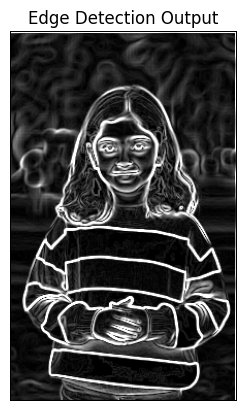

In [17]:
import cv2
from matplotlib import pyplot as plt

output_image = cv2.imread(
    '/content/Screenshot 2026-05-24 122048.png',
    cv2.IMREAD_GRAYSCALE
)

plt.imshow(output_image, cmap='gray')
plt.title('Edge Detection Output')
plt.axis('off')
plt.show()